# 🚀 Lab 23: Enhancing Plots with Annotations and Themes

### 📘 Lab Overview
In this lab, you will learn how to make plots more informative and more professional by adding **annotations**, **arrows**, **themes**, and **layout control**. You will use Matplotlib and Seaborn to highlight important points, improve readability, compare styles, and build dashboard-style figures.

You will work with multiple sample datasets including sales trends, student performance, and temperature data. By the end of the lab, you will know how to guide the viewer’s attention to important insights and how to present charts with a polished visual design.

This lab has been adapted for **Google Colab**, so all tasks run directly inside notebook cells without needing a separate cloud machine or terminal environment.

## 🎯 Objectives
By the end of this lab, students will be able to:
* Add text annotations and arrows to highlight important trends and data points
* Apply custom styles and themes including Seaborn themes such as `darkgrid`, `whitegrid`, and others
* Adjust figure size, spacing, and layout using `plt.subplots()` and `GridSpec`
* Combine multiple annotation techniques into informative and visually appealing plots
* Understand when and how to use different themes for different presentation styles
* Build professional dashboard-style figures with consistent styling

## 🧰 Prerequisites
Before starting this lab, students should have:
* Basic knowledge of Python programming
* Familiarity with Matplotlib and Seaborn
* Understanding of basic plot types such as line, scatter, and bar plots
* Experience with pandas for data handling

## ⚙️ Google Colab Environment Setup

### 💡 What is this for?
Think of this as setting up your desk before you start drawing. We are bringing in all the specialized tools (libraries) we need to create beautiful charts and manage our data.

We will use `%pip install` to ensure the latest versions are available, though Colab comes with most pre-installed.

In [1]:
# Install necessary libraries if they aren't already present
%pip install matplotlib seaborn pandas numpy

# Task 1: Setting Up the Environment and Data

## Subtask 1.1: Import Required Libraries
We import `matplotlib` for the core drawing engine and `seaborn` for high-level beautiful styles.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# Ignore unnecessary warning messages to keep our notebook clean
warnings.filterwarnings("ignore")

# Set a clean default theme so our initial plots look good
sns.set_style("whitegrid")

print("Libraries imported successfully.")
print("Seaborn version:", sns.__version__)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Libraries imported successfully.
Seaborn version: 0.13.2
Pandas version: 2.2.2
NumPy version: 2.0.2


## Subtask 1.2: 🗂 Creating Sample Data

### 💡 What is this for?
Before we can decorate a chart, we need something to plot! We are creating three fake datasets: sales numbers, school grades, and weather temperatures. This gives us variety to practice different techniques.

In [3]:
# Dataset 1: Sales data over time
# We use a random seed so the 'random' numbers are the same every time you run this.
np.random.seed(42)
dates = pd.date_range("2023-01-01", periods=12, freq="ME")

sales_data = pd.DataFrame({
    "date": dates,
    "sales": [100, 120, 140, 160, 180, 200, 190, 210, 230, 250, 240, 280],
    "profit": [20, 25, 30, 35, 40, 45, 42, 48, 52, 58, 55, 65]
})

# Dataset 2: Student performance data
subjects = ["Math", "Science", "English", "History", "Art"]
scores_2022 = [85, 78, 92, 88, 75]
scores_2023 = [88, 82, 94, 85, 80]

performance_data = pd.DataFrame({
    "subject": subjects,
    "scores_2022": scores_2022,
    "scores_2023": scores_2023
})

# Dataset 3: Temperature data with outliers
# Outliers are 'weird' data points that stand out from the rest.
np.random.seed(123)
temperature_data = pd.DataFrame({
    "day": range(1, 31),
    "temperature": np.random.normal(25, 5, 30)
})

# Manually adding outliers: a very hot day and a very cold day
temperature_data.loc[10, "temperature"] = 40   # Hot day outlier
temperature_data.loc[20, "temperature"] = 5    # Cold day outlier

print("Sample datasets created successfully!")

Sample datasets created successfully!


# Task 2: 🏷 Adding Annotations

### 💡 What is this for?
Annotations are like sticky notes on a chart. They tell the reader exactly what to look at so they don't have to guess why a line went up or down.

## Subtask 2.1: Basic Text Annotations
We will add simple text at specific coordinates.

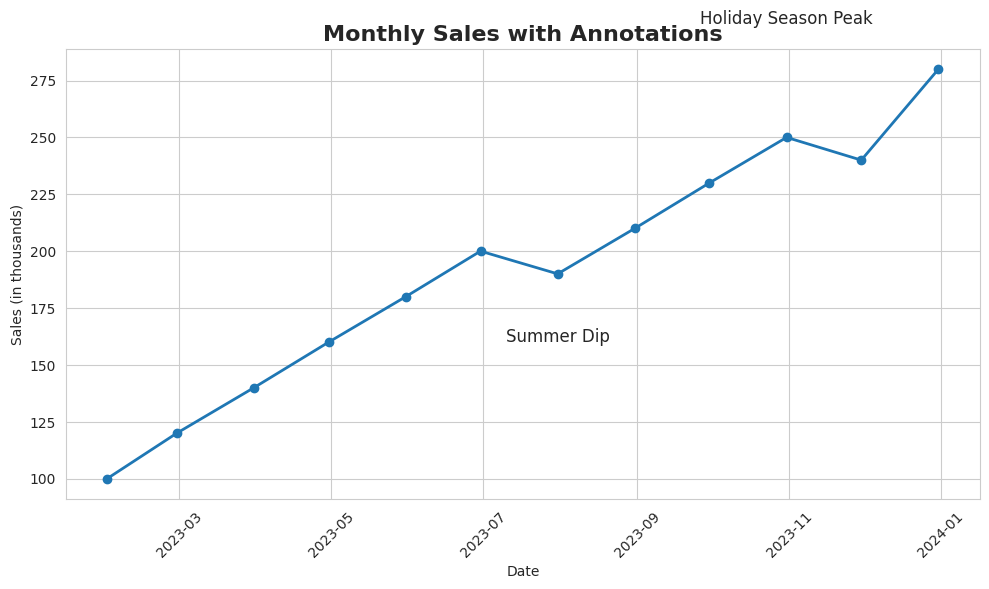

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(sales_data["date"], sales_data["sales"], marker="o", linewidth=2, markersize=6)

# plt.annotate adds text at a specific point (xy)
# xy: where the point is on the chart
# xytext: where the actual text label should float
plt.annotate(
    "Holiday Season Peak",
    xy=(sales_data["date"].iloc[-1], sales_data["sales"].iloc[-1]),
    xytext=(sales_data["date"].iloc[-3], sales_data["sales"].iloc[-1] + 20),
    fontsize=12,
    ha="center"
)

plt.annotate(
    "Summer Dip",
    xy=(sales_data["date"].iloc[6], sales_data["sales"].iloc[6]),
    xytext=(sales_data["date"].iloc[6], sales_data["sales"].iloc[6] - 30),
    fontsize=12,
    ha="center"
)

plt.title("Monthly Sales with Annotations", fontsize=16, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Sales (in thousands)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Subtask 2.2: Adding Arrows to Annotations
Arrows help connect our "sticky note" to the exact data point, especially in crowded charts.

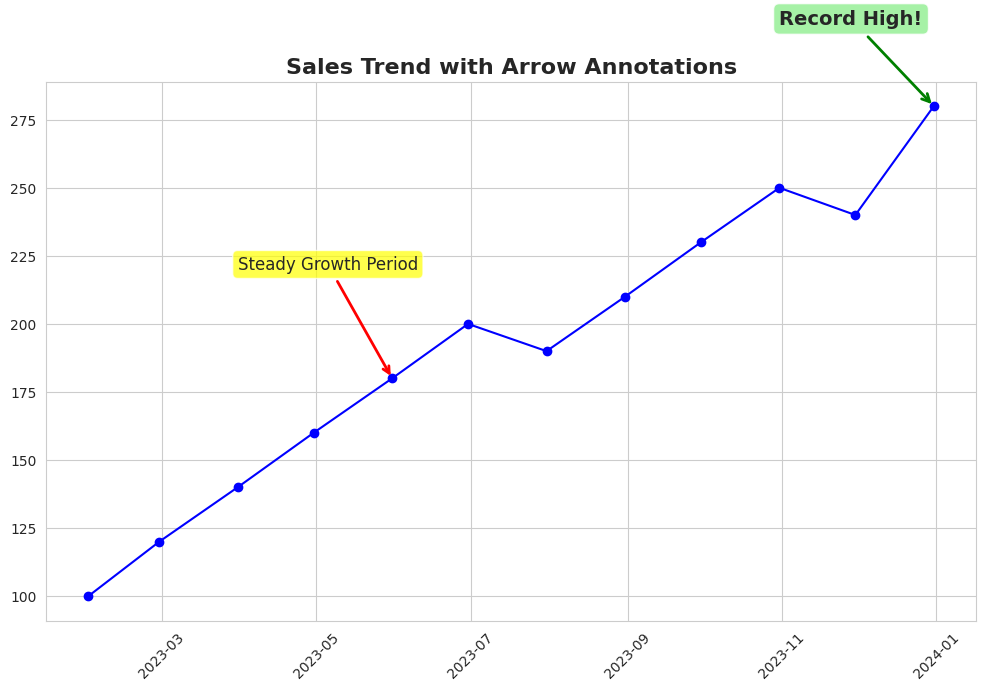

In [5]:
plt.figure(figsize=(12, 7))
plt.plot(sales_data["date"], sales_data["sales"], marker="o", color="blue")

# arrowprops creates the arrow connecting the text to the point
# bbox creates a nice box around the text to make it pop
plt.annotate(
    "Steady Growth Period",
    xy=(sales_data["date"].iloc[4], sales_data["sales"].iloc[4]),
    xytext=(sales_data["date"].iloc[2], sales_data["sales"].iloc[4] + 40),
    arrowprops=dict(arrowstyle="->", color="red", lw=2),
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7)
)

plt.annotate(
    "Record High!",
    xy=(sales_data["date"].iloc[-1], sales_data["sales"].iloc[-1]),
    xytext=(sales_data["date"].iloc[-3], sales_data["sales"].iloc[-1] + 30),
    arrowprops=dict(arrowstyle="->", color="green", lw=2),
    fontsize=14,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.8)
)

plt.title("Sales Trend with Arrow Annotations", fontsize=16, fontweight="bold")
plt.xticks(rotation=45)
plt.show()

## Subtask 2.3: Multiple Annotation Styles
Let's apply this to a scatter plot to identify outliers (the weird hot and cold days).

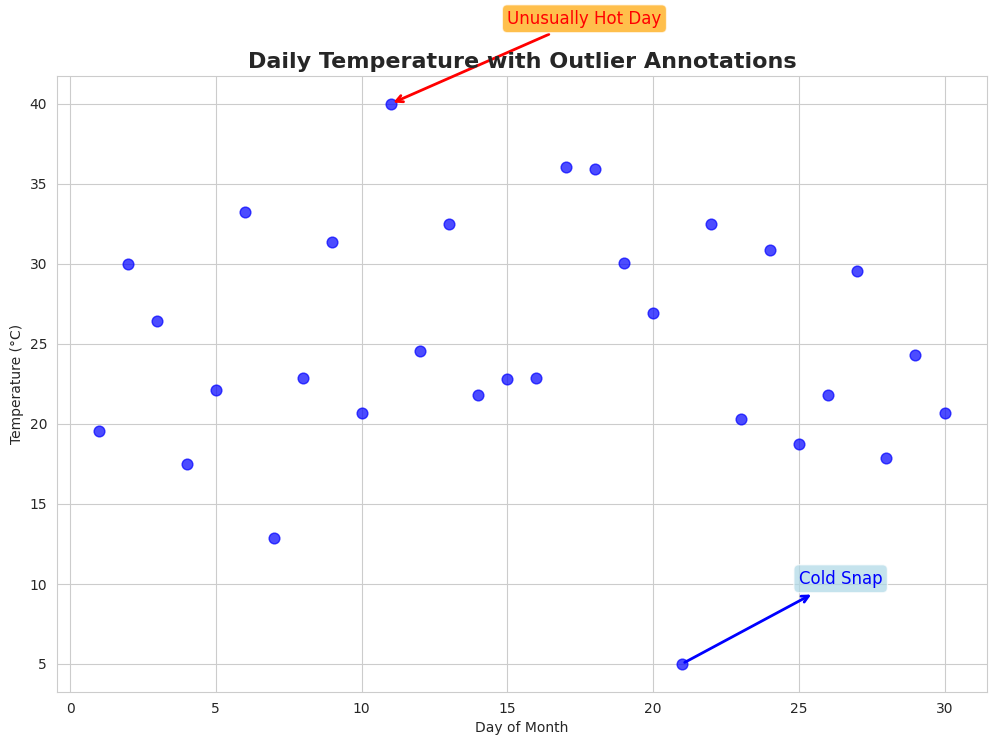

In [6]:
plt.figure(figsize=(12, 8))
plt.scatter(temperature_data["day"], temperature_data["temperature"], s=60, alpha=0.7, c="blue")

# Annotating the 'Hot Day' outlier
plt.annotate(
    "Unusually Hot Day",
    xy=(11, 40), xytext=(15, 45),
    arrowprops=dict(arrowstyle="->", color="red", lw=2),
    fontsize=12, color="red",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="orange", alpha=0.7)
)

# Annotating the 'Cold Snap' outlier
plt.annotate(
    "Cold Snap",
    xy=(21, 5), xytext=(25, 10),
    arrowprops=dict(arrowstyle="<-", color="blue", lw=2),
    fontsize=12, color="blue",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7)
)

plt.title("Daily Temperature with Outlier Annotations", fontsize=16, fontweight="bold")
plt.xlabel("Day of Month")
plt.ylabel("Temperature (°C)")
plt.show()

# Task 3: 🎨 Themes and Styles

### 💡 What is this for?
Changing the theme is like changing the filter on a photo. Different themes work better for different goals—some are better for printing on paper (white background), while others look cool on a computer screen (dark background).

## Subtask 3.1: Using Seaborn Themes
Let's compare how the same data looks in different preset themes.

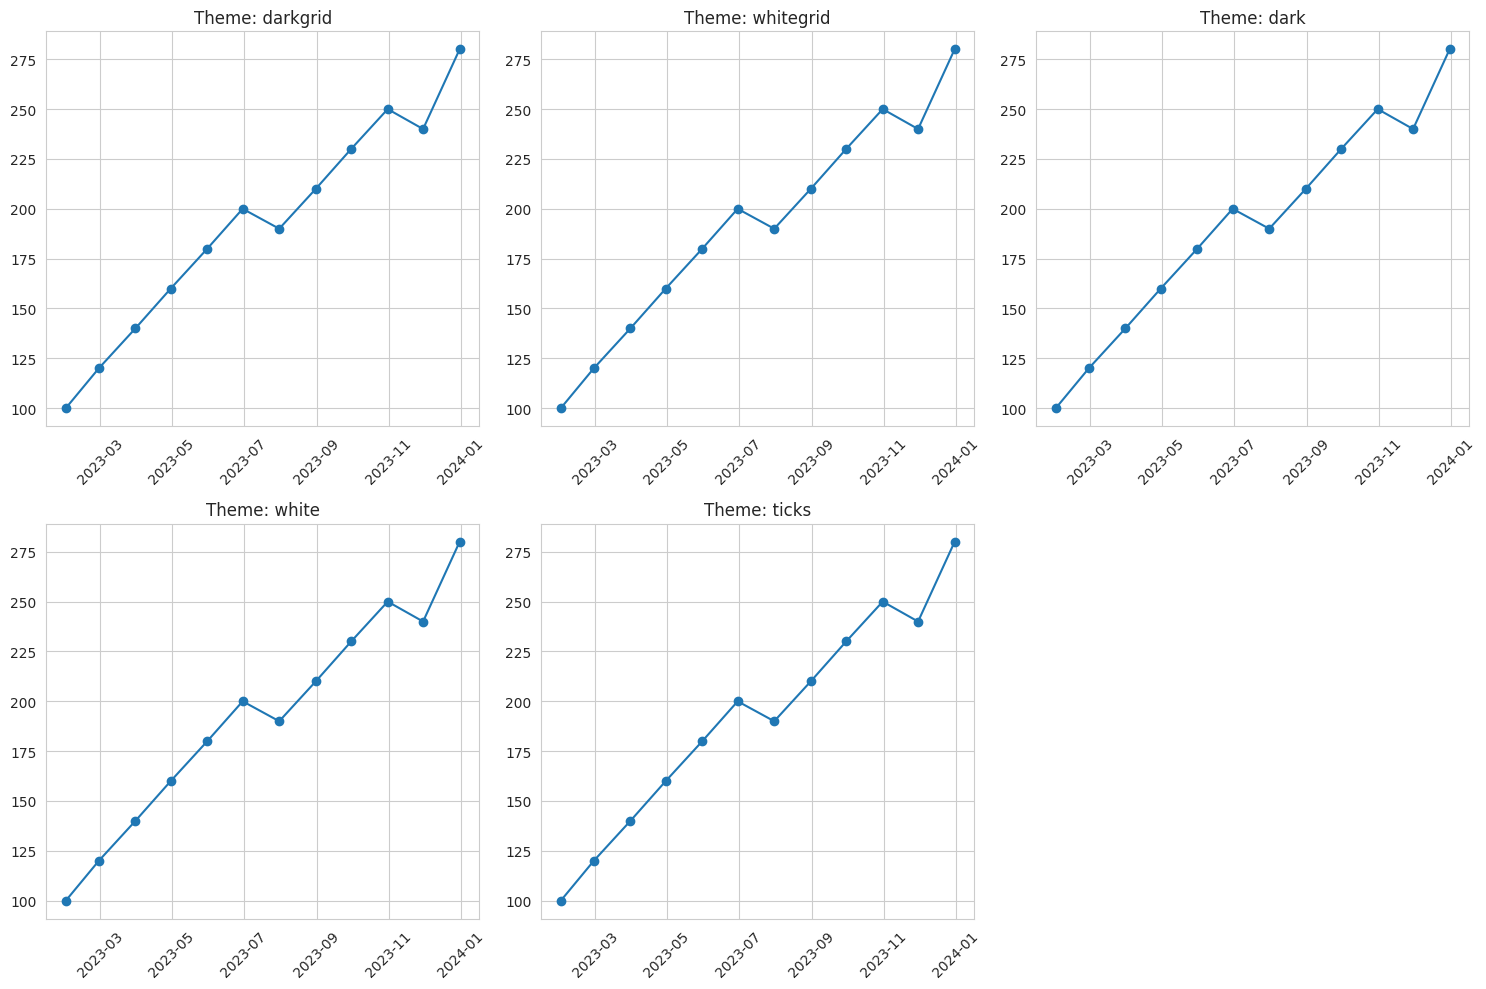

In [7]:
themes = ["darkgrid", "whitegrid", "dark", "white", "ticks"]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, theme in enumerate(themes):
    # We set the theme inside the loop to see the difference
    sns.set_style(theme)
    ax = axes[i]
    ax.plot(sales_data["date"], sales_data["sales"], marker="o")
    ax.set_title(f"Theme: {theme}")
    for label in ax.get_xticklabels():
        label.set_rotation(45)

# Remove the empty 6th subplot
axes[-1].remove()
plt.tight_layout()
plt.show()

# Reset to a standard theme
sns.set_style("whitegrid")

## Subtask 3.3: Dark Theme Implementation
Dark themes are very popular for high-tech dashboards and reducing eye strain.

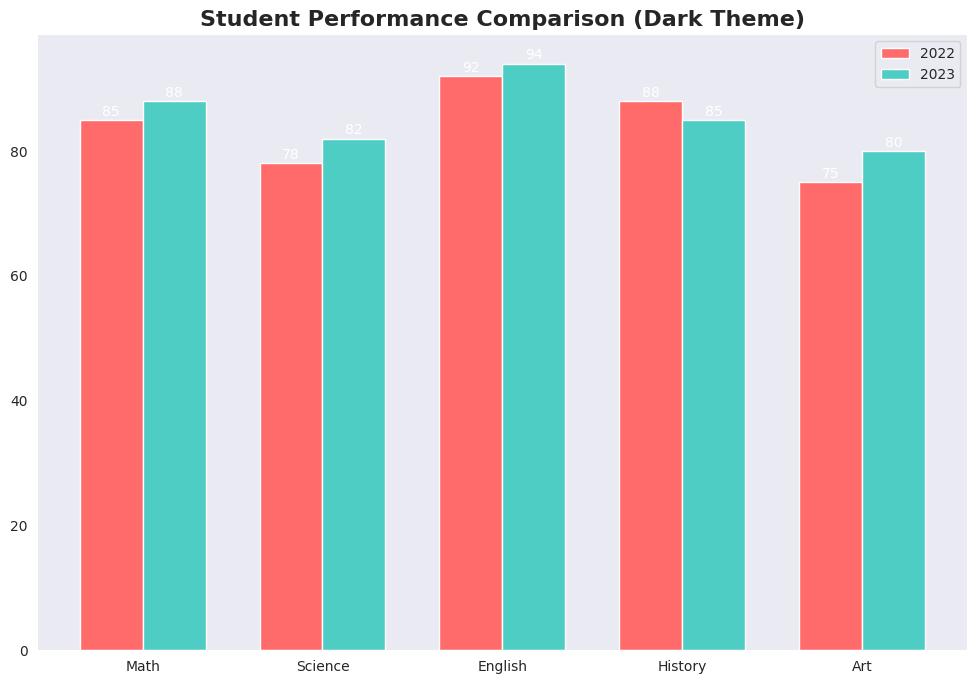

In [8]:
# plt.style.use changes the global Matplotlib settings
plt.style.use("dark_background")
sns.set_style("dark")

plt.figure(figsize=(12, 8))
x_pos = np.arange(len(performance_data["subject"]))
width = 0.35

# Creating a grouped bar chart
bars1 = plt.bar(x_pos - width/2, performance_data["scores_2022"], width, label="2022", color="#FF6B6B")
bars2 = plt.bar(x_pos + width/2, performance_data["scores_2023"], width, label="2023", color="#4ECDC4")

# Adding text labels on top of bars automatically
for bar in bars1 + bars2:
    height = bar.get_height()
    plt.annotate(f"{height}", xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0, 3), textcoords="offset points", ha="center", color="white")

plt.title("Student Performance Comparison (Dark Theme)", fontsize=16, fontweight="bold")
plt.xticks(x_pos, performance_data["subject"])
plt.legend()
plt.show()

# IMPORTANT: Reset styles back to default so following plots aren't dark
plt.style.use("default")
sns.set_style("whitegrid")

# Task 4: 🧱 Layout and Dashboards

### 💡 What is this for?
One chart is good, but a dashboard of charts is better! This section teaches you how to organize many charts neatly on one page using `subplots` and `GridSpec`.

## Subtask 4.2: Advanced Layout Control (GridSpec)
`GridSpec` allows us to make some charts bigger than others, like a newspaper layout.

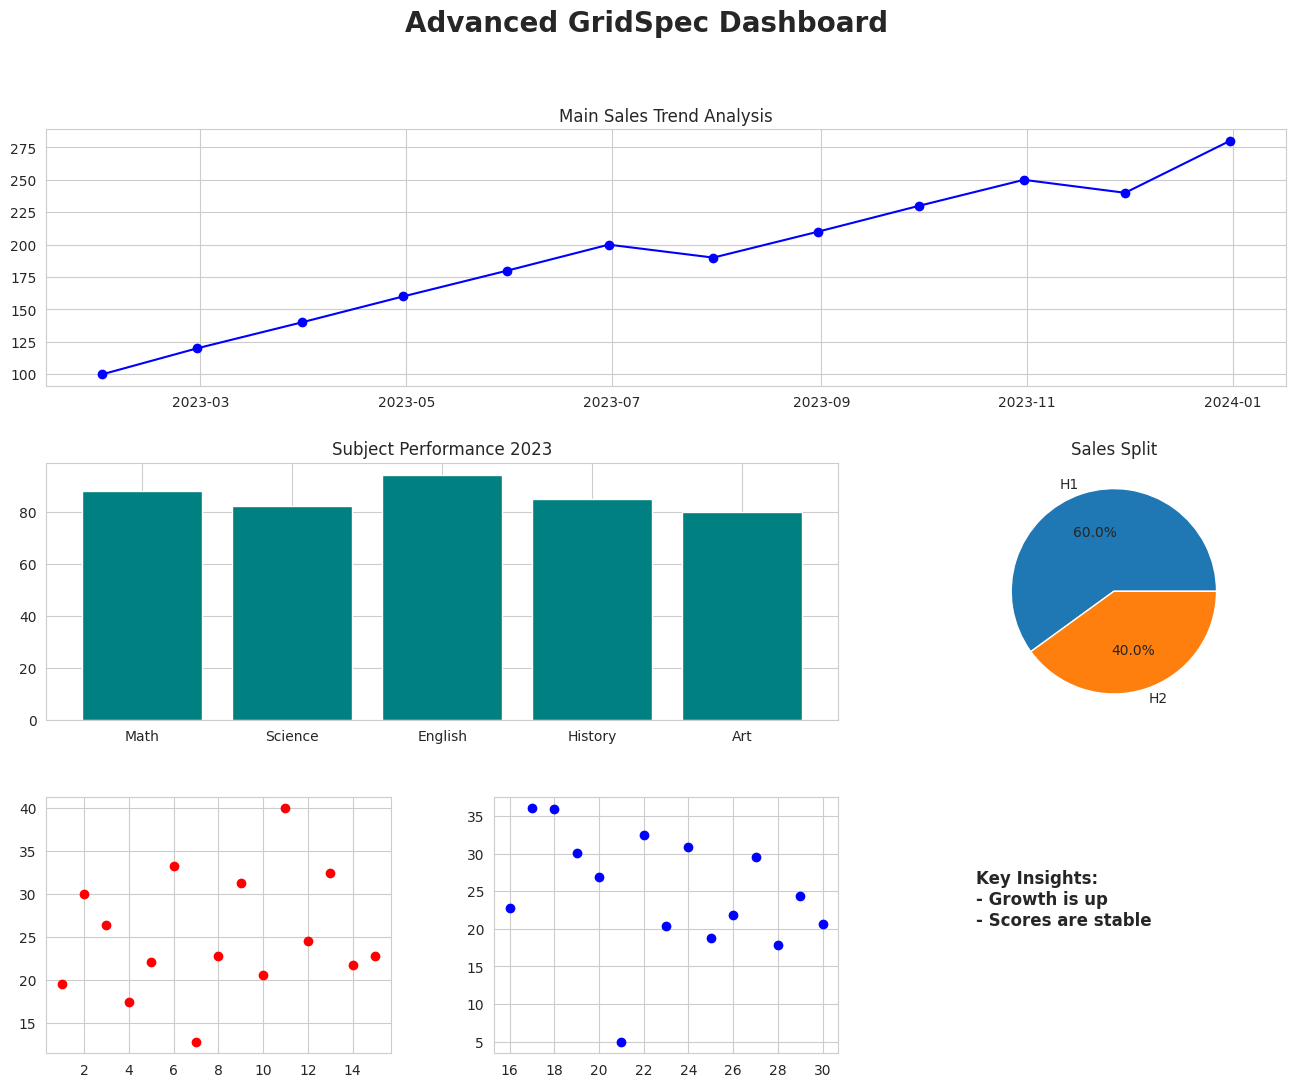

In [9]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(16, 12))
# We create a 3x3 grid
gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)

# Large top plot spans all 3 columns
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(sales_data["date"], sales_data["sales"], marker="o", color="blue")
ax1.set_title("Main Sales Trend Analysis")

# Medium plot spans 2 columns
ax2 = fig.add_subplot(gs[1, :2])
ax2.bar(performance_data["subject"], performance_data["scores_2023"], color="teal")
ax2.set_title("Subject Performance 2023")

# Pie chart in the 3rd column
ax3 = fig.add_subplot(gs[1, 2])
ax3.pie([60, 40], labels=["H1", "H2"], autopct="%1.1f%%")
ax3.set_title("Sales Split")

# Small scatter plots at the bottom
ax4 = fig.add_subplot(gs[2, 0])
ax4.scatter(temperature_data["day"][:15], temperature_data["temperature"][:15], color="red")

ax5 = fig.add_subplot(gs[2, 1])
ax5.scatter(temperature_data["day"][15:], temperature_data["temperature"][15:], color="blue")

# A text panel for insights
ax6 = fig.add_subplot(gs[2, 2])
ax6.text(0.1, 0.5, "Key Insights:\n- Growth is up\n- Scores are stable", fontsize=12, fontweight="bold")
ax6.axis("off")

plt.suptitle("Advanced GridSpec Dashboard", fontsize=20, fontweight="bold")
plt.show()

## Subtask 4.3: Professional Layout with Consistent Styling
This is our final, polished product using custom parameters and unified coloring.

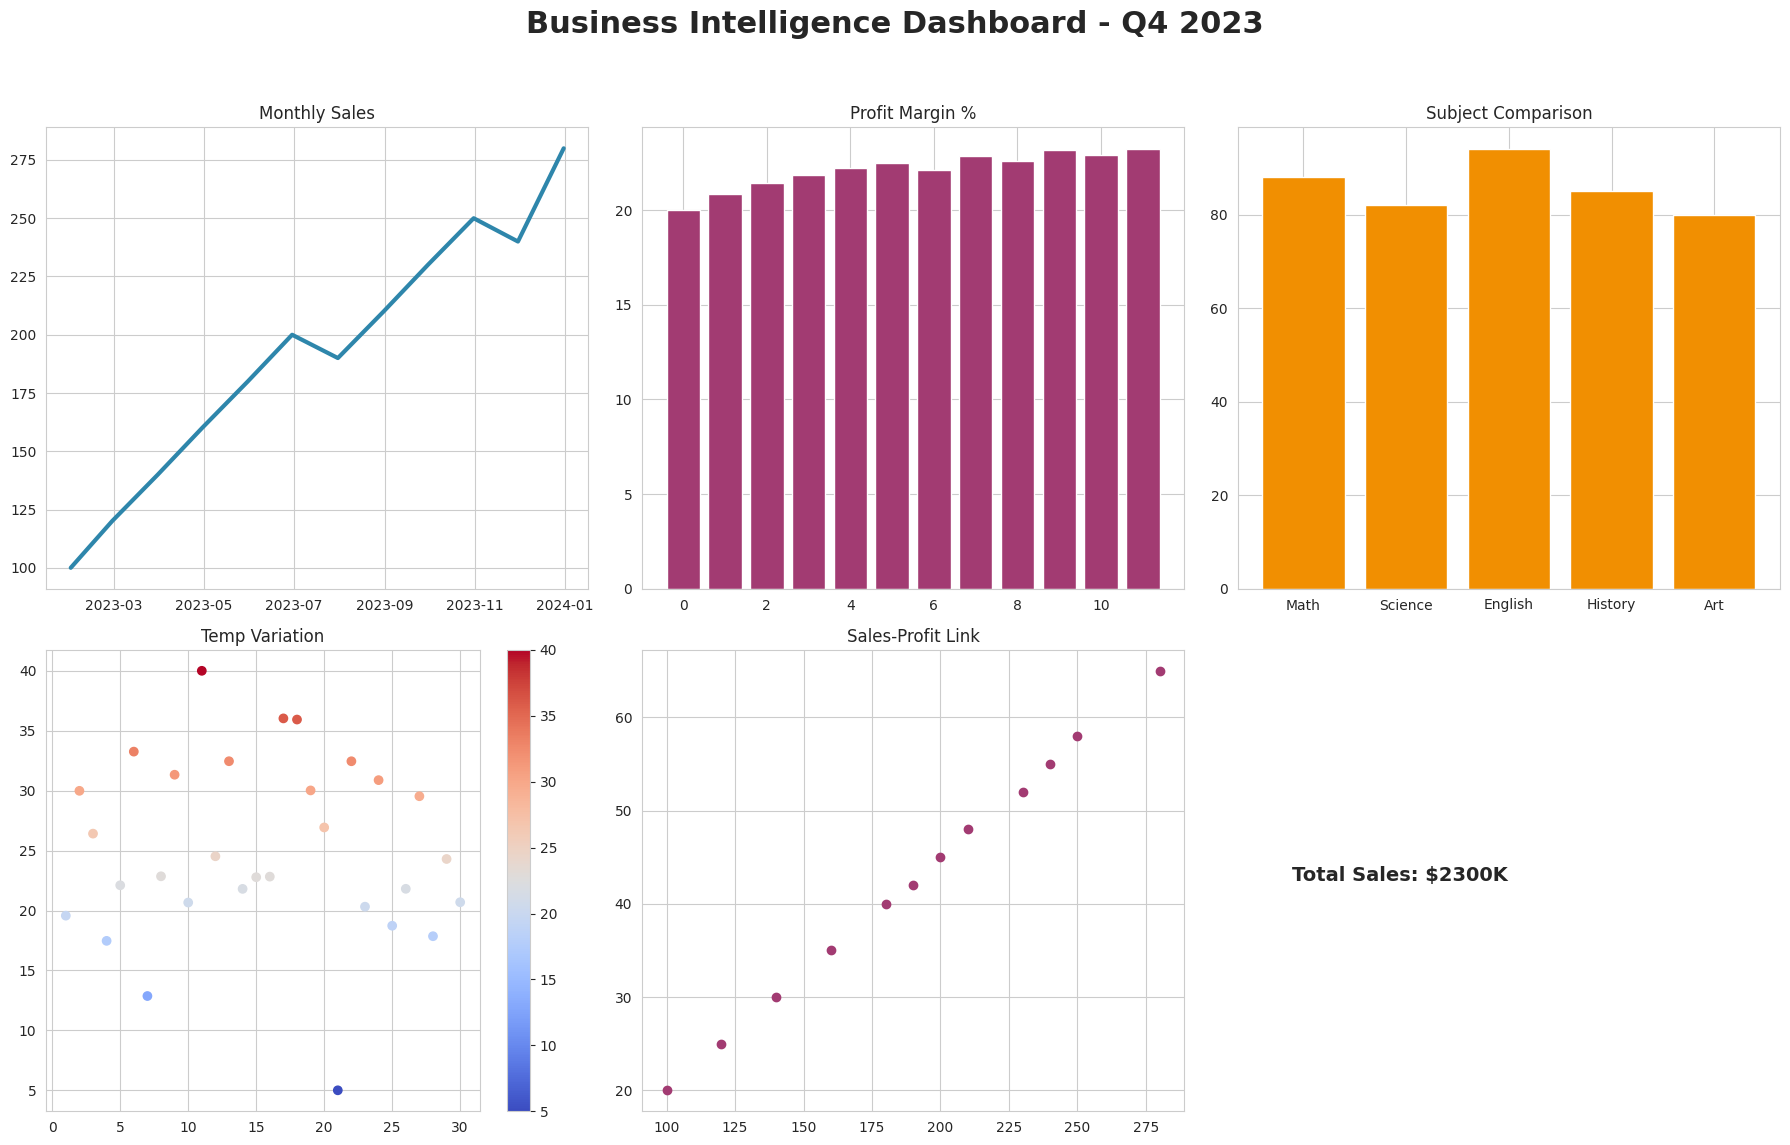

In [10]:
# Set consistent font sizes globally
plt.rcParams.update({"font.size": 10, "axes.titlesize": 12})

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Business Intelligence Dashboard - Q4 2023", fontsize=22, fontweight="bold")

colors = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D", "#4ECDC4"]

# Plot 1: Sales
axes[0,0].plot(sales_data["date"], sales_data["sales"], color=colors[0], lw=3)
axes[0,0].set_title("Monthly Sales")

# Plot 2: Profit Margin
profit_margin = (sales_data["profit"] / sales_data["sales"]) * 100
axes[0,1].bar(range(len(profit_margin)), profit_margin, color=colors[1])
axes[0,1].set_title("Profit Margin %")

# Plot 3: Comparison
axes[0,2].bar(performance_data["subject"], performance_data["scores_2023"], color=colors[2])
axes[0,2].set_title("Subject Comparison")

# Plot 4: Temperature Heatmap-style scatter
sc = axes[1,0].scatter(temperature_data["day"], temperature_data["temperature"], c=temperature_data["temperature"], cmap="coolwarm")
plt.colorbar(sc, ax=axes[1,0])
axes[1,0].set_title("Temp Variation")

# Plot 5: Correlation
axes[1,1].scatter(sales_data["sales"], sales_data["profit"], color=colors[1])
axes[1,1].set_title("Sales-Profit Link")

# Plot 6: Summary
axes[1,2].text(0.1, 0.5, f"Total Sales: ${sum(sales_data['sales'])}K", fontsize=14, fontweight="bold")
axes[1,2].axis("off")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## ✅ Verification Checklist
- [ ] Libraries imported without error
- [ ] Datasets created and verified
- [ ] Text and Arrow annotations correctly point to data
- [ ] Seaborn themes (light and dark) display correctly
- [ ] GridSpec and Subplots create neat dashboard layouts
- [ ] Theme reset executed after dark-theme section

## 🛠 Troubleshooting Guide
- **Text Overlap:** Use `ha='left'` or `ha='right'` in `plt.annotate` to shift text alignment.
- **Arrows not showing:** Ensure `xy` (target) and `xytext` (label) are different coordinates.
- **Plot too small:** Increase `figsize` in `plt.figure()` or `plt.subplots()`.
- **Labels cut off:** Always call `plt.tight_layout()` at the end of your plot code.

## 📚 Key Takeaways
- **Annotations** guide the user's eye to the 'story' in the data.
- **Themes** set the mood and professional tone of the report.
- **Dashboards** allow for comparing multiple metrics side-by-side.
- **Visual Hierarchy** ensures the most important data is the most prominent.

## 🎓 Conclusion
You've mastered the art of making charts "presentation-ready." By combining annotations, themes, and layout controls, you can now transform raw data plots into professional-grade business or scientific reports.

**What I learned:**
- How to use `annotate` with arrows.
- How to switch between Seaborn styles.
- How to manage complex layouts with `GridSpec`.

**Real-World Application:**
These techniques are used daily by Data Scientists to create executive dashboards, publish research papers, and present financial findings to stakeholders.